In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\ML\KNN\Heart Prediction Quantum Dataset.csv")

In [4]:
df.head()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1


In [5]:
df.tail()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
495,34,0,126,292,116,9.303403,0
496,41,0,164,248,114,9.067889,0
497,45,1,159,175,75,8.718708,0
498,55,0,107,157,101,7.337650,1
499,55,0,174,249,89,10.492950,0


In [6]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


In [8]:
df.shape

(500, 7)

In [9]:
df.isnull().sum()

Age                      0
Gender                   0
BloodPressure            0
Cholesterol              0
HeartRate                0
QuantumPatternFeature    0
HeartDisease             0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

Age


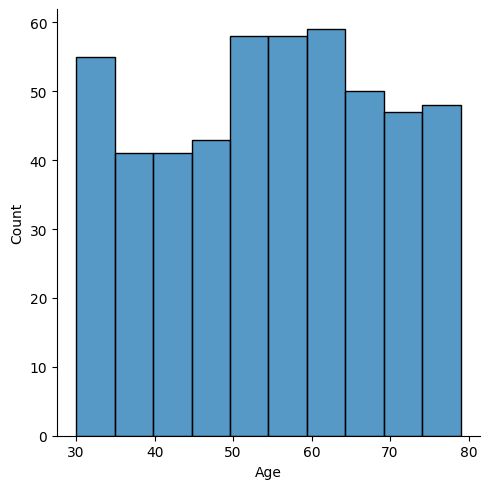

Gender


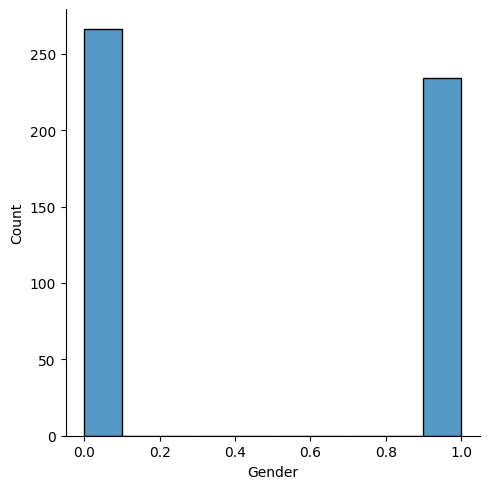

BloodPressure


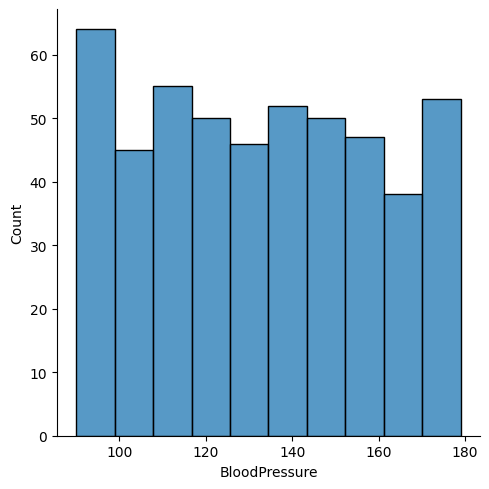

Cholesterol


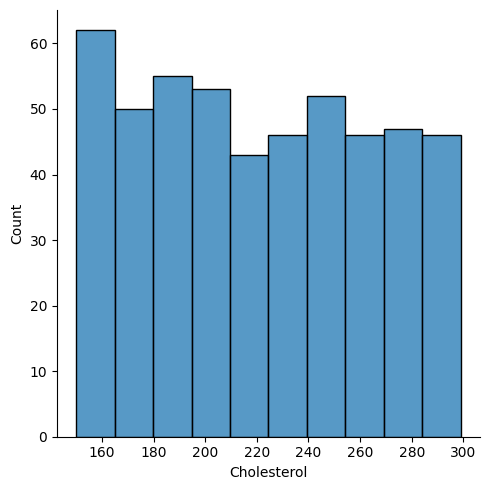

HeartRate


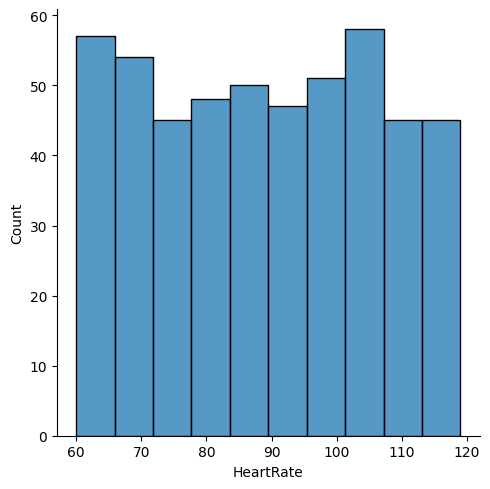

QuantumPatternFeature


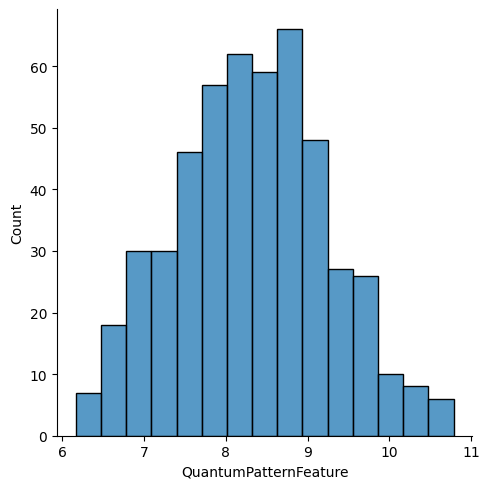

HeartDisease


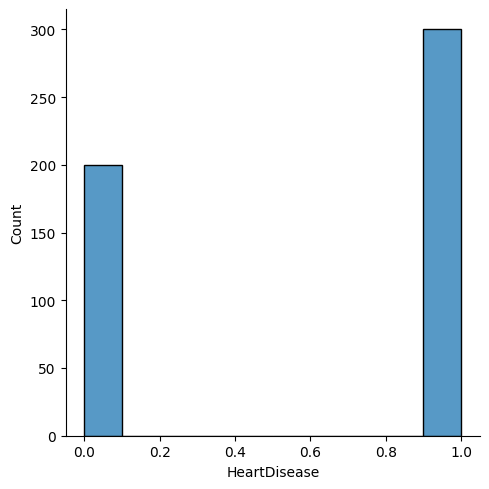

In [11]:
for col_name in df.columns:
    print(col_name)
    sns.displot(df[col_name])
    plt.show()

Age


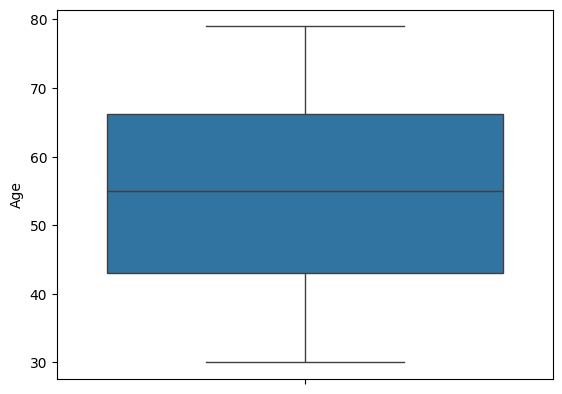

Gender


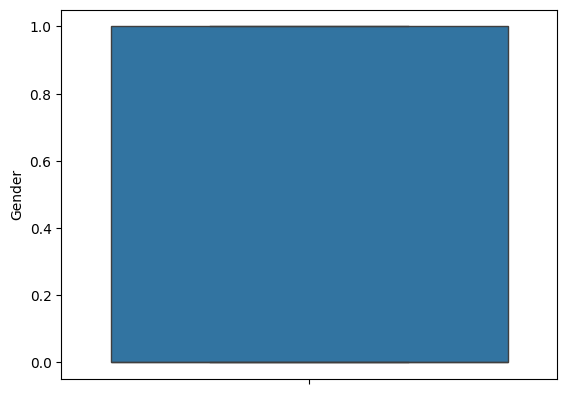

BloodPressure


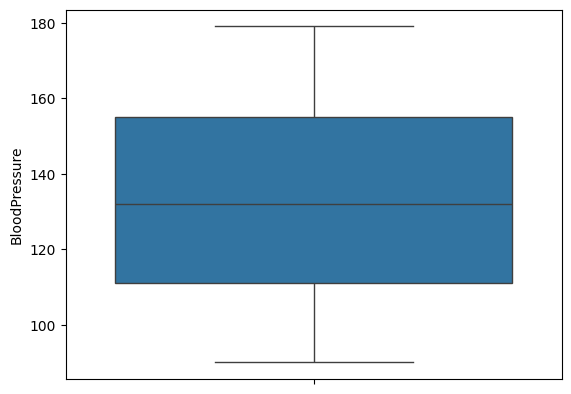

Cholesterol


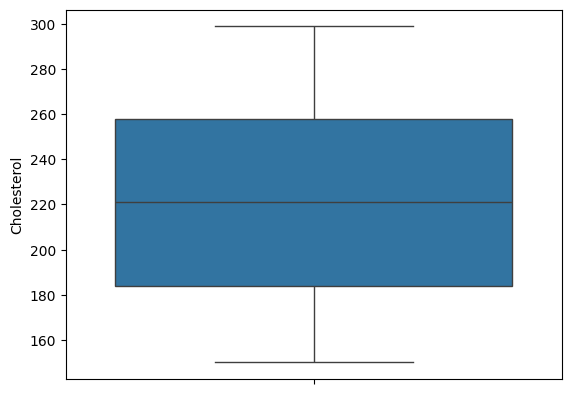

HeartRate


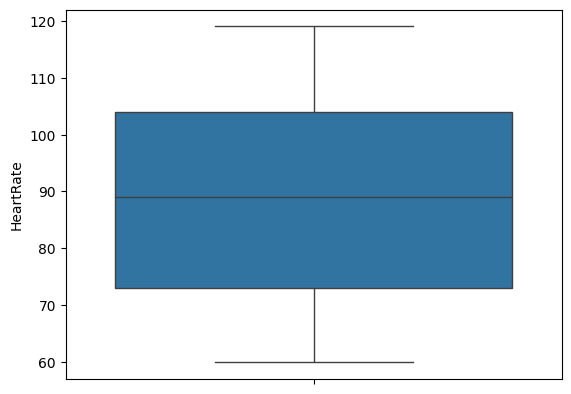

QuantumPatternFeature


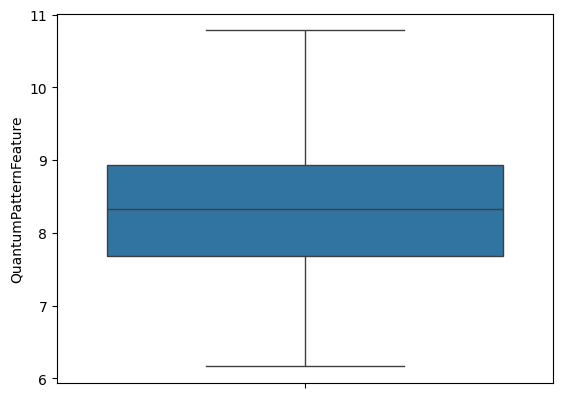

HeartDisease


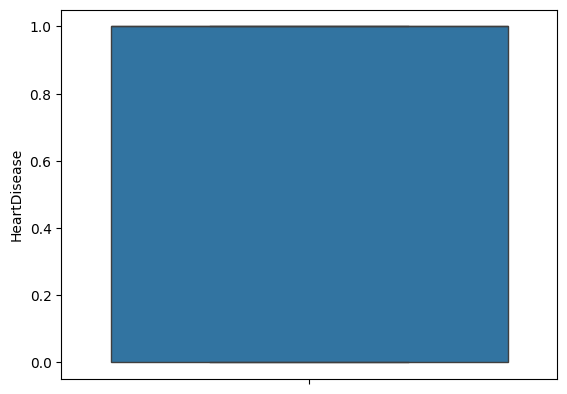

In [12]:
for col_name in df.columns:
    print(col_name)
    sns.boxplot(df[col_name])
    plt.show()

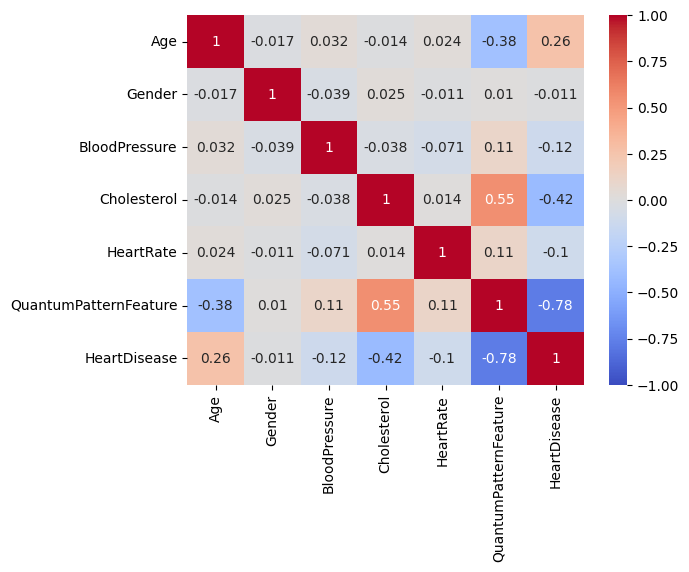

In [13]:
sns.heatmap(df.corr (), annot = True , vmin = -1 , vmax = 1 ,cmap= 'coolwarm')
plt.show()
            

In [14]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [15]:
print(X.shape)
print(y.shape)

(500, 6)
(500,)


In [16]:
from sklearn.preprocessing import StandardScaler

# average = 0
# std dev = 1
ss = StandardScaler()
X = ss.fit_transform(X)

In [17]:
print(X)

[[ 0.91855759  1.06618579 -1.05615    -0.69603327  1.04793927  0.04880027]
 [ 0.21929024 -0.93792284 -1.35927119  0.62757098  0.01344838  1.01402539]
 [-0.75968405 -0.93792284 -1.51083178 -0.71885403 -0.38885363 -0.40803503]
 ...
 [-0.68975732  1.06618579  0.98991802 -1.06116548 -0.79115564  0.43680885]
 [ 0.00951004 -0.93792284 -0.9803697  -1.47193921  0.70310897 -1.06645064]
 [ 0.00951004 -0.93792284  1.55827025  0.62757098  0.01344838  2.36804362]]


In [18]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y , test_size = 0.2)

In [19]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(400, 6)
(100, 6)
(400,)
(100,)


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

error_li = []

for k in range (1,21):
    knn = KNeighborsClassifier ( n_neighbors = k , metric = 'euclidean')
    knn.fit(X_train , y_train)
    y_pred = knn.predict(X_test)
    error = 1 - accuracy_score(y_test,y_pred)
    error_li.append(error)

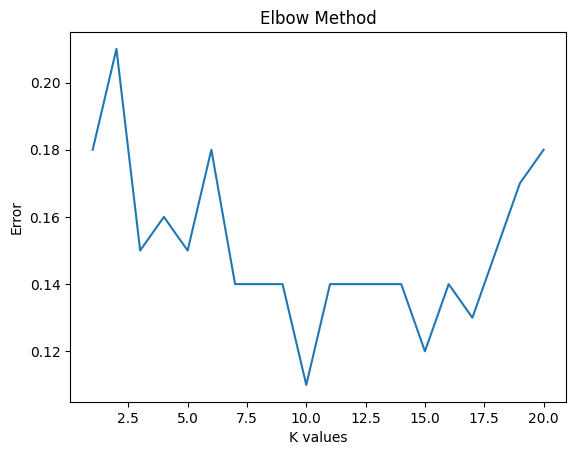

In [26]:
plt.title('Elbow Method')
plt.plot(range(1,21),error_li)
plt.xlabel('K values')
plt.ylabel('Error')
plt.show()

In [29]:
knn = KNeighborsClassifier(n_neighbors=10, metric='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.85        36
           1       0.93      0.89      0.91        64

    accuracy                           0.89       100
   macro avg       0.88      0.89      0.88       100
weighted avg       0.89      0.89      0.89       100

